In [15]:
import numpy as np
import pandas as pd

In [16]:
from google.colab import files

uploaded = files.upload()

Saving laptop_price.csv to laptop_price (1).csv


In [17]:
data = pd.read_csv("laptop_price.csv" , encoding="latin-1")

In [18]:
#Extracting Features from ScreenResolution

data['Touchscreen'] = data['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)

data['Ips'] = data['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)

In [19]:
data.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Touchscreen,Ips
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69,0,1
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94,0,0
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00,0,0
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45,0,1
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60,0,1


In [20]:
#Processing CPU Column

data['cpu_name'] = data['Cpu'].apply(lambda x:" ".join(x.split()[0:3]))

def set_processor(name):
    if name in ['Intel Core i7','Intel Core i5','Intel Core i3']:
        return name
    elif name.split()[0] == 'AMD':
        return 'AMD'
    else:
        return 'Other'
data['cpu_name'] = data['cpu_name'].apply(set_processor)

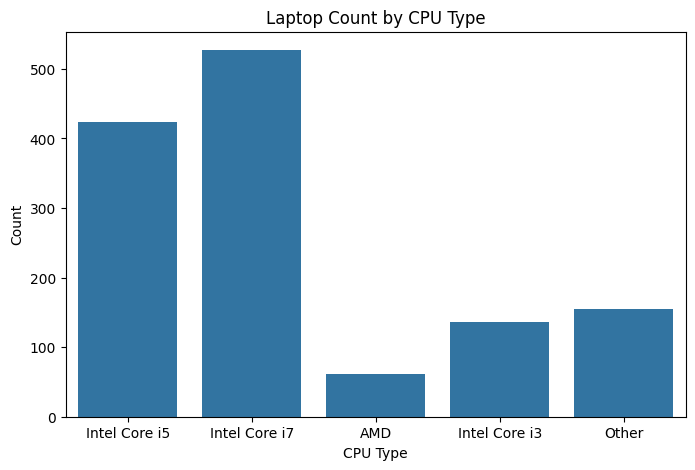

In [21]:
# Visualization - CPU distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x="cpu_name", data=data)
plt.title("Laptop Count by CPU Type")
plt.xlabel("CPU Type")
plt.ylabel("Count")
plt.show()

In [22]:
# Processing GPU Column
data['gpu_name'] = data['Gpu'].apply(lambda x:" ".join(x.split()[0:1]))

data = data[data['gpu_name'] != 'ARM']

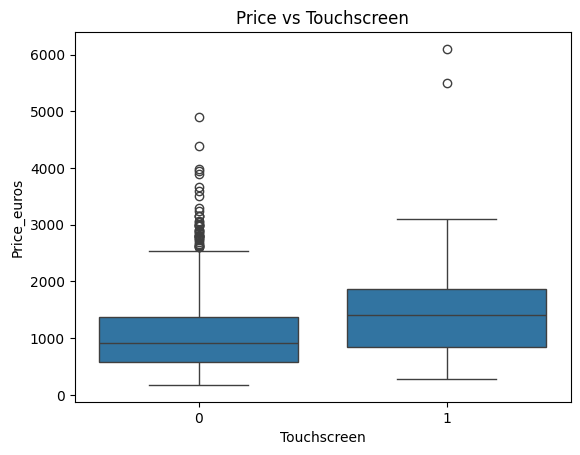

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Touchscreen", y="Price_euros", data=data)
plt.title("Price vs Touchscreen")
plt.show()
# Boxplot shows touchscreen laptops are generally more expensive.

In [24]:
# Function to remove outliers using IQR
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

In [25]:
cleaned_data = remove_outliers(data, "Price_euros")

In [26]:
#Drop column
final_data = cleaned_data.drop(columns=['Product','ScreenResolution','Cpu','Gpu','Memory'])

In [27]:
#One hot encoding
final_data = pd.get_dummies(final_data)